# HW13: BERT Tokenization, Inference, and Fine-tuning

## 1. Imports and Setup

In [1]:
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
import warnings
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')

Device: cuda
PyTorch version: 2.10.0+cu128


## 2. Data Loading and Analysis

In [2]:
dataset = load_dataset('emotion')
print(f'Train size: {len(dataset["train"])}')
print(f'Validation size: {len(dataset["validation"])}')
print(f'Test size: {len(dataset["test"])}')

label_names = dataset['train'].features['label'].names
print(f'\nClasses: {label_names}')
print(f'Number of classes: {len(label_names)}')

README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Train size: 16000
Validation size: 2000
Test size: 2000

Classes: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
Number of classes: 6


In [3]:
print('Sample texts and labels:')
for i in range(5):
    sample = dataset['train'][i]
    print(f"{i+1}. [{label_names[sample['label']]}] {sample['text'][:80]}...")

Sample texts and labels:
1. [sadness] i didnt feel humiliated...
2. [sadness] i can go from feeling so hopeless to so damned hopeful just from being around so...
3. [anger] im grabbing a minute to post i feel greedy wrong...
4. [love] i am ever feeling nostalgic about the fireplace i will know that it is still on ...
5. [anger] i am feeling grouchy...


## 3. Tokenization Analysis

In [4]:
model_name = 'distilbert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(model_name)

print(f'Tokenizer: {model_name}')
print(f'Vocabulary size: {tokenizer.vocab_size}')
print(f'Special tokens: {tokenizer.special_tokens_map}')

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer: distilbert-base-uncased
Vocabulary size: 30522
Special tokens: {'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}


In [5]:
sample_texts = dataset['train'][:3]['text']

for idx, text in enumerate(sample_texts):
    print(f'\n--- Sample {idx+1} ---')
    print(f'Text: {text[:60]}...')

    tokens = tokenizer.tokenize(text)
    print(f'Tokens: {tokens[:15]}...')

    encoded = tokenizer(text, return_tensors='pt', padding=True, truncation=True, max_length=128)
    print(f'Input IDs shape: {encoded["input_ids"].shape}')
    print(f'Attention mask shape: {encoded["attention_mask"].shape}')
    print(f'Tokens count: {encoded["input_ids"].shape[1]}')


--- Sample 1 ---
Text: i didnt feel humiliated...
Tokens: ['i', 'didn', '##t', 'feel', 'humiliated']...
Input IDs shape: torch.Size([1, 7])
Attention mask shape: torch.Size([1, 7])
Tokens count: 7

--- Sample 2 ---
Text: i can go from feeling so hopeless to so damned hopeful just ...
Tokens: ['i', 'can', 'go', 'from', 'feeling', 'so', 'hopeless', 'to', 'so', 'damned', 'hopeful', 'just', 'from', 'being', 'around']...
Input IDs shape: torch.Size([1, 23])
Attention mask shape: torch.Size([1, 23])
Tokens count: 23

--- Sample 3 ---
Text: im grabbing a minute to post i feel greedy wrong...
Tokens: ['im', 'grabbing', 'a', 'minute', 'to', 'post', 'i', 'feel', 'greedy', 'wrong']...
Input IDs shape: torch.Size([1, 12])
Attention mask shape: torch.Size([1, 12])
Tokens count: 12


In [6]:
short_text = "Great movie!"
long_text = " ".join(["word"] * 200)

print('Padding and truncation demo:')
print(f'\nShort text tokens: {tokenizer(short_text, max_length=10, padding="max_length")["input_ids"]}')
print(f'Long text (truncated): {tokenizer(long_text, max_length=20, truncation=True)["input_ids"]}')

Padding and truncation demo:

Short text tokens: [101, 2307, 3185, 999, 102, 0, 0, 0, 0, 0]
Long text (truncated): [101, 2773, 2773, 2773, 2773, 2773, 2773, 2773, 2773, 2773, 2773, 2773, 2773, 2773, 2773, 2773, 2773, 2773, 2773, 102]


## 4. Pretrained Model Inference

In [7]:
pretrained_model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(label_names)
).to(DEVICE)
pretrained_model.eval()

print(f'Model loaded: {model_name}')

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded: distilbert-base-uncased


In [8]:
test_texts = [
    "I love this so much!",
    "This is terrible and makes me angry",
    "I feel so sad today",
    "That's cool and interesting",
    "I'm shocked by this news"
]

print('Pretrained model inference on sample texts:')
with torch.no_grad():
    for text in test_texts:
        inputs = tokenizer(text, return_tensors='pt', padding=True, truncation=True, max_length=128).to(DEVICE)
        outputs = pretrained_model(**inputs)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=-1)
        pred_label = torch.argmax(probs, dim=-1).item()
        confidence = probs[0, pred_label].item()

        print(f'Text: "{text}"')
        print(f'Prediction: {label_names[pred_label]} (confidence: {confidence:.2f})')
        print()

Pretrained model inference on sample texts:
Text: "I love this so much!"
Prediction: anger (confidence: 0.19)

Text: "This is terrible and makes me angry"
Prediction: anger (confidence: 0.19)

Text: "I feel so sad today"
Prediction: anger (confidence: 0.19)

Text: "That's cool and interesting"
Prediction: anger (confidence: 0.18)

Text: "I'm shocked by this news"
Prediction: anger (confidence: 0.18)



## 5. Data Preparation for Fine-tuning

In [9]:
MAX_LENGTH = 128

def tokenize_function(examples):
    return tokenizer(
        examples['text'],
        padding='max_length',
        truncation=True,
        max_length=MAX_LENGTH
    )

dataset_tokenized = dataset.map(tokenize_function, batched=True)
dataset_tokenized = dataset_tokenized.remove_columns('text')
dataset_tokenized.set_format('torch')

print(f'Tokenized dataset prepared')
print(f'Train: {len(dataset_tokenized["train"])}')
print(f'Validation: {len(dataset_tokenized["validation"])}')
print(f'Test: {len(dataset_tokenized["test"])}')

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Tokenized dataset prepared
Train: 16000
Validation: 2000
Test: 2000


## 6. Fine-tuning

In [10]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(label_names)
)

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    warmup_steps=100,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
)

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    accuracy = accuracy_score(labels, predictions)
    f1_macro = f1_score(labels, predictions, average='macro')
    return {'accuracy': accuracy, 'f1_macro': f1_macro}

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset_tokenized['train'],
    eval_dataset=dataset_tokenized['validation'],
    compute_metrics=compute_metrics,
)

print('Starting fine-tuning...')
trainer.train()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Starting fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.228521,0.196561,0.932000,0.907547
2,0.085756,0.131920,0.936500,0.909450
3,0.065916,0.130431,0.942000,0.917315


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=1500, training_loss=0.2552912889122963, metrics={'train_runtime': 571.4605, 'train_samples_per_second': 83.995, 'train_steps_per_second': 2.625, 'total_flos': 1589722177536000.0, 'train_loss': 0.2552912889122963, 'epoch': 3.0})

## 7. Evaluation on Test Set

In [11]:
eval_results = trainer.evaluate(dataset_tokenized['test'])
print(f'Test Accuracy: {eval_results["eval_accuracy"]:.4f}')
print(f'Test F1 Macro: {eval_results["eval_f1_macro"]:.4f}')

Test Accuracy: 0.9280
Test F1 Macro: 0.8801


## 8. Predictions and Analysis

In [15]:
predictions_output = trainer.predict(dataset_tokenized['test'])
logits = predictions_output.predictions
true_labels = predictions_output.label_ids

probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()
pred_labels = np.argmax(logits, axis=1)

test_texts_full = dataset['test']['text']

predictions_df = pd.DataFrame({
    'text': test_texts_full,
    'true_label': [label_names[i] for i in true_labels],
    'pred_label': [label_names[i] for i in pred_labels],
    'confidence': np.max(probs, axis=1)
})

predictions_df.to_csv('artifacts/sample_predictions.csv', index=False)
print(f'Saved {len(predictions_df)} predictions')
print(predictions_df.head(10))

Saved 2000 predictions
                                                text true_label pred_label  \
0  im feeling rather rotten so im not very ambiti...    sadness    sadness   
1          im updating my blog because i feel shitty    sadness    sadness   
2  i never make her separate from me because i do...    sadness    sadness   
3  i left with my bouquet of red and yellow tulip...        joy        joy   
4    i was feeling a little vain when i did this one    sadness    sadness   
5  i cant walk into a shop anywhere where i do no...       fear       fear   
6   i felt anger when at the end of a telephone call      anger      anger   
7  i explain why i clung to a relationship with a...        joy        joy   
8  i like to have the same breathless feeling as ...        joy        joy   
9  i jest i feel grumpy tired and pre menstrual w...      anger      anger   

   confidence  
0    0.998948  
1    0.999217  
2    0.999151  
3    0.999387  
4    0.999089  
5    0.998030  
6    0

## 9. Confusion Matrix

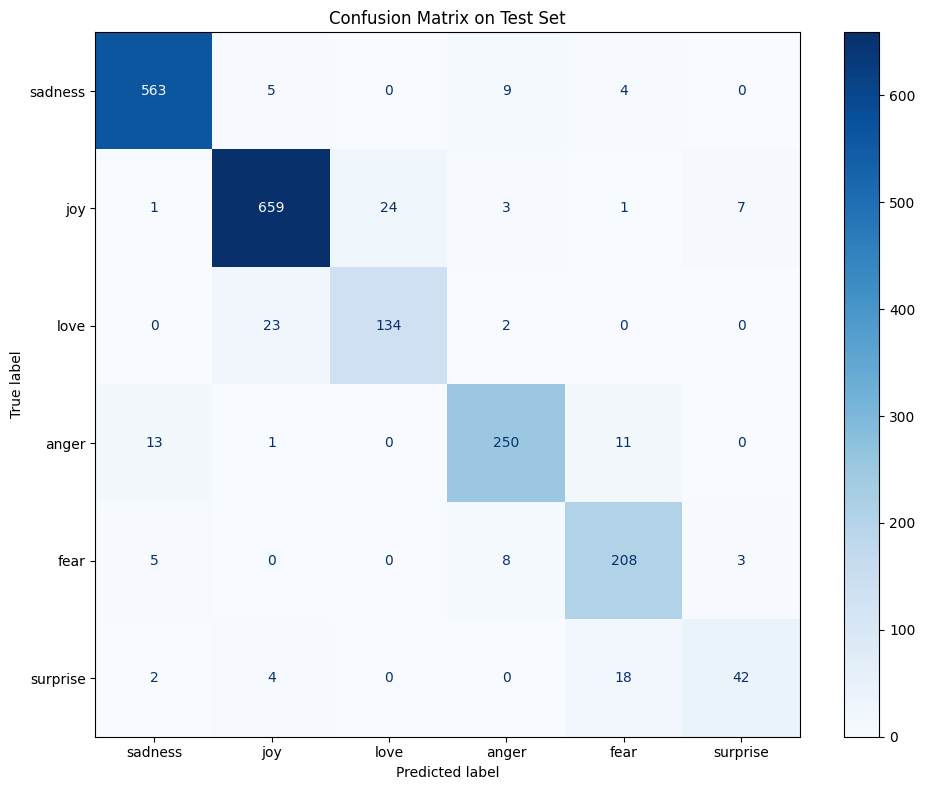

Confusion matrix saved


In [17]:
cm = confusion_matrix(true_labels, pred_labels)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix on Test Set')
plt.tight_layout()
plt.savefig('artifacts/confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

print('Confusion matrix saved')

## 10. Error Analysis

In [18]:
errors = predictions_df[predictions_df['true_label'] != predictions_df['pred_label']]
print(f'Total errors: {len(errors)} out of {len(predictions_df)}')
print(f'Error rate: {len(errors)/len(predictions_df)*100:.1f}%')

print('\nSample errors:')
for idx, row in errors.head(10).iterrows():
    print(f"Text: {row['text'][:60]}...")
    print(f"True: {row['true_label']}, Pred: {row['pred_label']}, Conf: {row['confidence']:.2f}")
    print()

Total errors: 144 out of 2000
Error rate: 7.2%

Sample errors:
Text: i don t feel particularly agitated...
True: fear, Pred: anger, Conf: 0.73

Text: i feel if i completely hated things i d exercise my democrat...
True: anger, Pred: sadness, Conf: 0.60

Text: i feel a bit stressed even though all the things i have goin...
True: anger, Pred: sadness, Conf: 0.62

Text: i am right handed however i play billiards left handed natur...
True: surprise, Pred: fear, Conf: 0.77

Text: i feel like i am in paradise kissing those sweet lips make m...
True: joy, Pred: love, Conf: 0.67

Text: when a friend dropped a frog down my neck...
True: anger, Pred: fear, Conf: 0.81

Text: i feel my heart is tortured by what i have done...
True: anger, Pred: fear, Conf: 0.69

Text: i feel agitated with myself that i did not foresee her frust...
True: fear, Pred: anger, Conf: 0.50

Text: i feel very mislead by someone that i really really thought ...
True: love, Pred: anger, Conf: 0.96

Text: im feeling generous

## 11. Metrics Summary

In [19]:
accuracy = accuracy_score(true_labels, pred_labels)
f1_macro = f1_score(true_labels, pred_labels, average='macro')
f1_per_class = f1_score(true_labels, pred_labels, average=None)

print(f'Test Accuracy: {accuracy:.4f}')
print(f'Test F1 Macro: {f1_macro:.4f}')
print(f'\nF1 per class:')
for label, f1 in zip(label_names, f1_per_class):
    print(f'  {label}: {f1:.4f}')

Test Accuracy: 0.9280
Test F1 Macro: 0.8801

F1 per class:
  sadness: 0.9665
  joy: 0.9503
  love: 0.8454
  anger: 0.9141
  fear: 0.8927
  surprise: 0.7119
